In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load dataset
df = pd.read_excel(
    "../datasets/student_feedback.xlsx"
)

In [ ]:
#inspect the dataset

In [4]:
#check the row
df.head()

,teaching,teaching.1,coursecontent,coursecontent.1,examination,Examination,labwork,labwork.1,library_facilities,library_facilities,extracurricular,extracurricular.1
0,0,teacher are punctual but they should also give...,0.0,content of courses are average,1.0,examination pattern is good,-1,"not satisfactory, lab work must include latest...",0.0,library facilities are good but number of book...,1,extracurricular activities are excellent and p...
1,1,Good,-1.0,Not good,1.0,Good,1,Good,-1.0,Not good,1,Good
2,1,Excellent lectures are delivered by teachers a...,1.0,All courses material provide very good knowled...,1.0,Exam pattern is up to the mark and the Cgpa de...,1,Lab work is properly covered in the labs by th...,1.0,Library facilities are excellent in terms of g...,1,Extra curricular activities also help students...
3,1,Good,-1.0,Content of course is perfectly in line with th...,-1.0,Again the university tests students of their a...,1,Good,0.0,Its the best thing i have seen in this univers...,-1,Complete wastage of time. Again this opinion i...
4,1,teachers give us all the information required ...,1.0,content of courses improves my knowledge,1.0,examination pattern is good,1,practical work provides detail knowledge of th...,1.0,library has huge collection of books from diff...,1,extracurricular activities increases mental an...


In [5]:
#check shape
df.shape

(185, 12)

In [7]:
# check column
df.columns

Index(['teaching', 'teaching.1', 'coursecontent', 'coursecontent.1',
       'examination', 'Examination', 'labwork', 'labwork.1',
       'library_facilities', ' library_facilities', 'extracurricular',
       'extracurricular.1'],
      dtype='str')

In [8]:
#check missing values
df.isnull().sum()

teaching               0
teaching.1             0
coursecontent          1
coursecontent.1        0
examination            1
Examination            0
labwork                0
labwork.1              0
library_facilities     3
 library_facilities    0
extracurricular        0
extracurricular.1      0
dtype: int64

In [9]:
#there is diff type of column and diff values
#create column pairs
column_pairs = [

    ("teaching", "teaching.1"),

    ("coursecontent", "coursecontent.1"),

    ("examination", "Examination"),

    ("labwork", "labwork.1"),

    (
        "library_facilities",
        " library_facilities"
    ),

    (
        "extracurricular",
        "extracurricular.1"
    )
]

In [10]:
# create a empty list
data = []

In [11]:
#CONVERT WIDE FORMAT → LONG FORMAT
for label_col, review_col in column_pairs:

    temp = pd.DataFrame()

    temp["review"] = df[review_col]

    temp["label"] = df[label_col]

    temp["domain"] = label_col

    data.append(temp)

In [12]:
#merge evrything for cleaner look

student_df = pd.concat(
    data,
    ignore_index=True
)

In [13]:
#check the output
student_df.head()

,review,label,domain
0,teacher are punctual but they should also give...,0.0,teaching
1,Good,1.0,teaching
2,Excellent lectures are delivered by teachers a...,1.0,teaching
3,Good,1.0,teaching
4,teachers give us all the information required ...,1.0,teaching


In [14]:
#remove null values
student_df.dropna(inplace=True)

In [15]:
#remove duplicate
student_df.drop_duplicates(
    subset=["review"],
    inplace=True
)

In [ ]:
#again checking dataset info
student_df.info()

<class 'pandas.DataFrame'>
Index: 652 entries, 0 to 1109
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   review  652 non-null    str    
 1   label   652 non-null    float64
 2   domain  652 non-null    str    
dtypes: float64(1), str(2)
memory usage: 68.1 KB


In [17]:
#convert label into sentiments
def convert_sentiment(label):

    if label == 1:
        return "Positive"

    elif label == 0:
        return "Neutral"

    else:
        return "Negative"
    
#apply this function
student_df["sentiment"] = (
    student_df["label"]
    .apply(convert_sentiment)
)

In [18]:
#check sentiments 
student_df[
    ["label", "sentiment"]
].head()

,label,sentiment
0,0.0,Neutral
1,1.0,Positive
2,1.0,Positive
3,1.0,Positive
4,1.0,Positive


In [ ]:
student_df.columns
# bcz at end we have (review sentiment rating domain)

Index(['review', 'label', 'domain', 'sentiment'], dtype='str')

In [21]:
def sentiment_to_rating(sentiment):

    if sentiment == "Positive":
        return 8

    elif sentiment == "Neutral":
        return 5

    else:
        return 2

student_df["rating"] = (
    student_df["sentiment"]
    .apply(sentiment_to_rating)
)

In [22]:
#create review length
student_df["review_length"] = (
    student_df["review"]
    .apply(len)
)

In [23]:
student_df.head()

,review,label,domain,sentiment,rating,review_length
0,teacher are punctual but they should also give...,0.0,teaching,Neutral,5,100
1,Good,1.0,teaching,Positive,8,5
2,Excellent lectures are delivered by teachers a...,1.0,teaching,Positive,8,80
3,Good,1.0,teaching,Positive,8,4
4,teachers give us all the information required ...,1.0,teaching,Positive,8,73


Now come EDA part

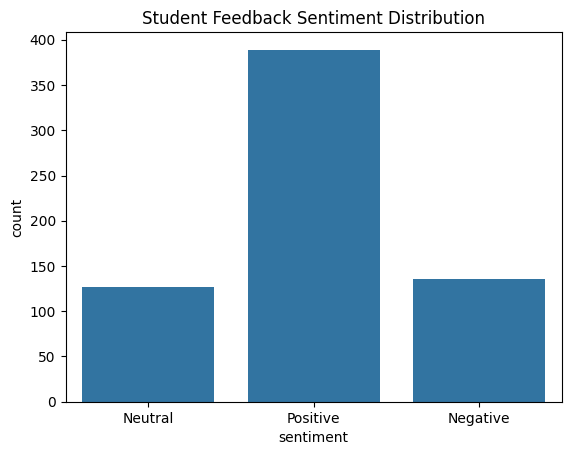

In [ ]:
#sentiment distribution
sns.countplot(
    x="sentiment",
    data=student_df
)

plt.title(
    "Student Feedback Sentiment Distribution"
)

plt.show()

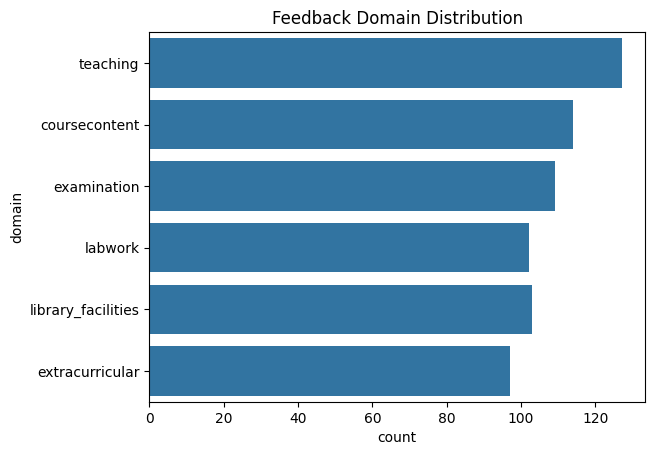

In [25]:
#domain distribution
sns.countplot(
    y="domain",
    data=student_df
)

plt.title("Feedback Domain Distribution")

plt.show()

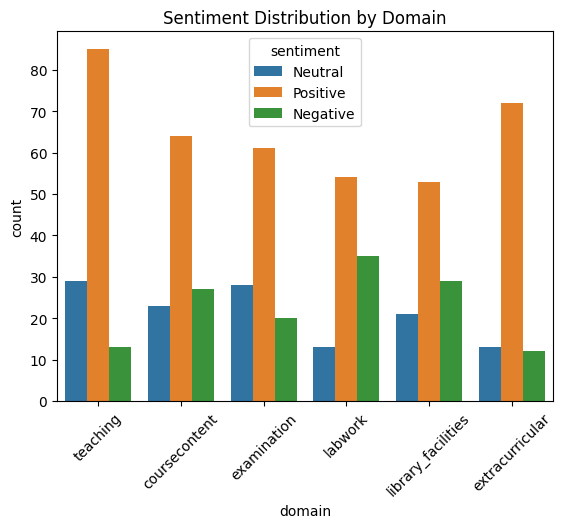

In [ ]:
#sentiment by domain
sns.countplot(
    x="domain",
    hue="sentiment",
    data=student_df
)

plt.xticks(rotation=45)

plt.title(
    "Sentiment Distribution by Domain"
)

plt.show()

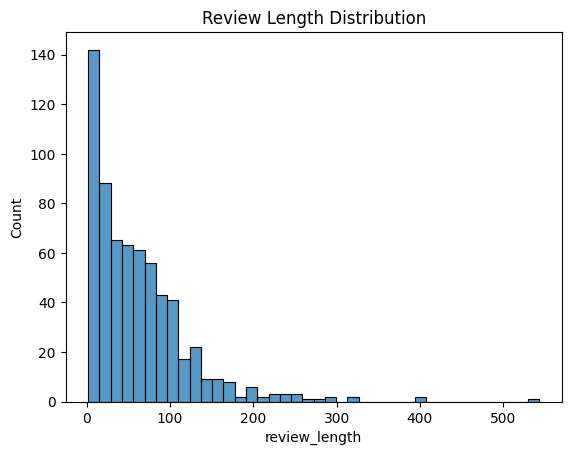

In [27]:
#REVIEW LENGTH DISTRIBUTION
sns.histplot(
    student_df["review_length"],
    bins=40
)

plt.title(
    "Review Length Distribution"
)

plt.show()

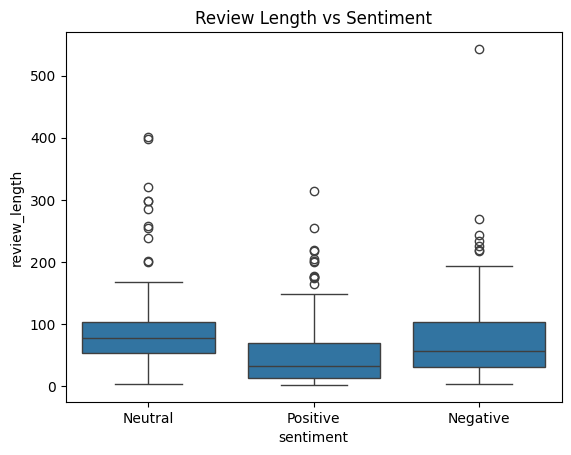

In [28]:
# REVIEW LENGTH VS SENTIMENT
sns.boxplot(
    x="sentiment",
    y="review_length",
    data=student_df
)

plt.title(
    "Review Length vs Sentiment"
)

plt.show()

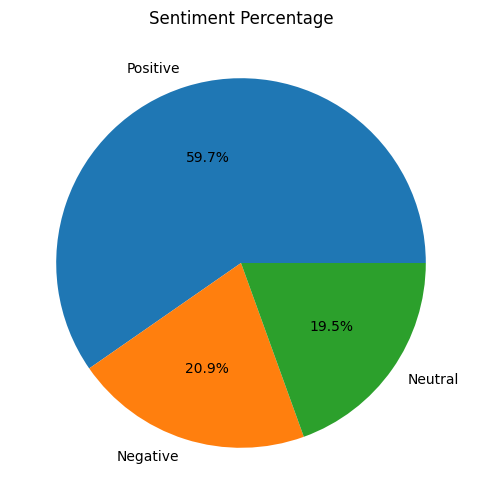

In [29]:
student_df["sentiment"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Sentiment Percentage")

plt.ylabel("")

plt.show()

now it come NPL preprocessing means text preprocessing

In [30]:
#import library
import re
import nltk
#download nltk resource
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/anthony/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/anthony/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/anthony/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [31]:
#import nltk tool
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [32]:
#create stop word and lemmatizer
stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

In [41]:
#create cleaning and apply cleanig
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", " ", text)

    # remove html tags
    text = re.sub(r"<.*?>", " ", text)

    # remove numbers
    text = re.sub(r"\d+", " ", text)

    # remove punctuation/special chars
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    # tokenize
    words = text.split()

    # remove stopwords + lemmatization
    words = [

    lemmatizer.lemmatize(word)

    for word in words

    if word not in stop_words
    and len(word) > 2
    ]

    # join words
    return " ".join(words)

student_df["clean_review"] = (
    student_df["review"]
    .apply(clean_text)
)

In [42]:
#check after cleaning
student_df[
    ["review", "clean_review"]
].head()

,review,clean_review
0,teacher are punctual but they should also give...,teacher punctual also give practical knowledge...
1,Good,good
2,Excellent lectures are delivered by teachers a...,excellent lecture delivered teacher teacher pu...
3,Good,good
4,teachers give us all the information required ...,teacher give information required improve perf...


In [43]:
#check empty review
student_df[
    student_df["clean_review"] == ""
]

,review,label,domain,sentiment,rating,review_length,clean_review
93,it is ok,1.0,teaching,Positive,8,8,
237,ok,1.0,coursecontent,Positive,8,2,
583,ok ok,1.0,labwork,Positive,8,5,


In [44]:
#remove empty 
student_df = student_df[
    student_df["clean_review"] != ""
]

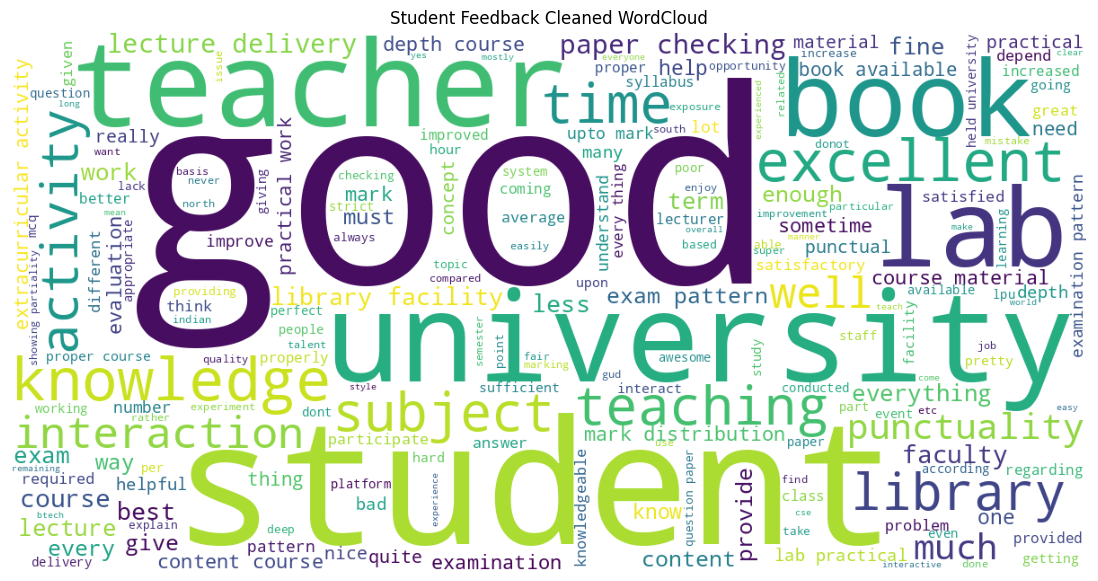

In [45]:
#creatig word cloud
from wordcloud import WordCloud
#combine text
text = " ".join(
    student_df["clean_review"]
)
#create word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)
#plot
plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Student Feedback Cleaned WordCloud"
)

plt.show()

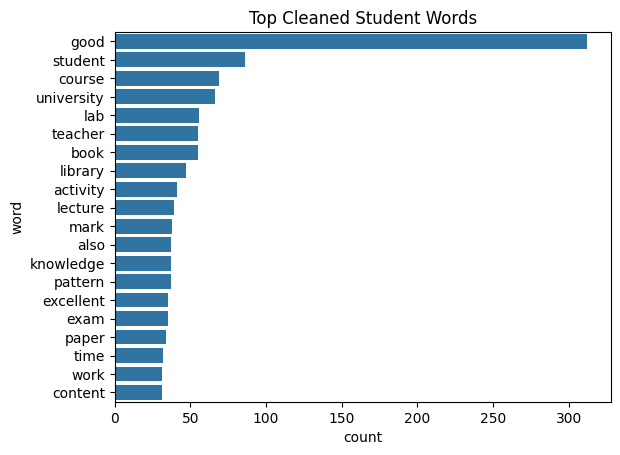

In [46]:
# top cleaned word
from collections import Counter
#extract word
all_words = " ".join(
    student_df["clean_review"]
).split()
#count word
common_words = Counter(
    all_words
).most_common(20)
#create dataframe
common_df = pd.DataFrame(
    common_words,
    columns=["word", "count"]
)
#plot
sns.barplot(
    x="count",
    y="word",
    data=common_df
)

plt.title(
    "Top Cleaned Student Words"
)

plt.show()

In [47]:
#domian wise word cloud
#teaching word cloud
teaching_text = " ".join(

    student_df[
        student_df["domain"] == "teaching"
    ]["clean_review"]

)
#lab word clod
lab_text = " ".join(

    student_df[
        student_df["domain"] == "labwork"
    ]["clean_review"]

)

In [48]:
#finally save the data
student_df.to_csv(
    "../processed_data/student_processed.csv",
    index=False
)